# [LAB 11] 3. 분해 시계열이란


In [1]:
# 라이브러리 기본 참조
from hossam import load_data
from helpers import *

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.31


## 연습문제 - 서울 기온 보고서 : 계절 탓인가, 정말 이상한 해였나
![alt text](image-19.png)

In [2]:
df1 = load_data('temperatures_seoul')
df1.head()

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)


,날짜,평균기온(℃)
0,1973-07-01,26.816
1,1973-08-01,25.884
2,1973-09-01,20.323
3,1973-10-01,13.039
4,1973-11-01,4.723


In [3]:
# 월단위 데이터임을 알림 --> freq='MS' (Month Start)
df2 = my_ts.set_index(df1, '날짜', freq='MS')
print('인덱스 간격(freq):', df2.index.freqstr)
df2.head()

인덱스 간격(freq): MS


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323
1973-10-01,13.039
1973-11-01,4.723


결합 방식 자동 판정: additive
관측치 602개 중 추세·잔차가 계산된 구간 590개


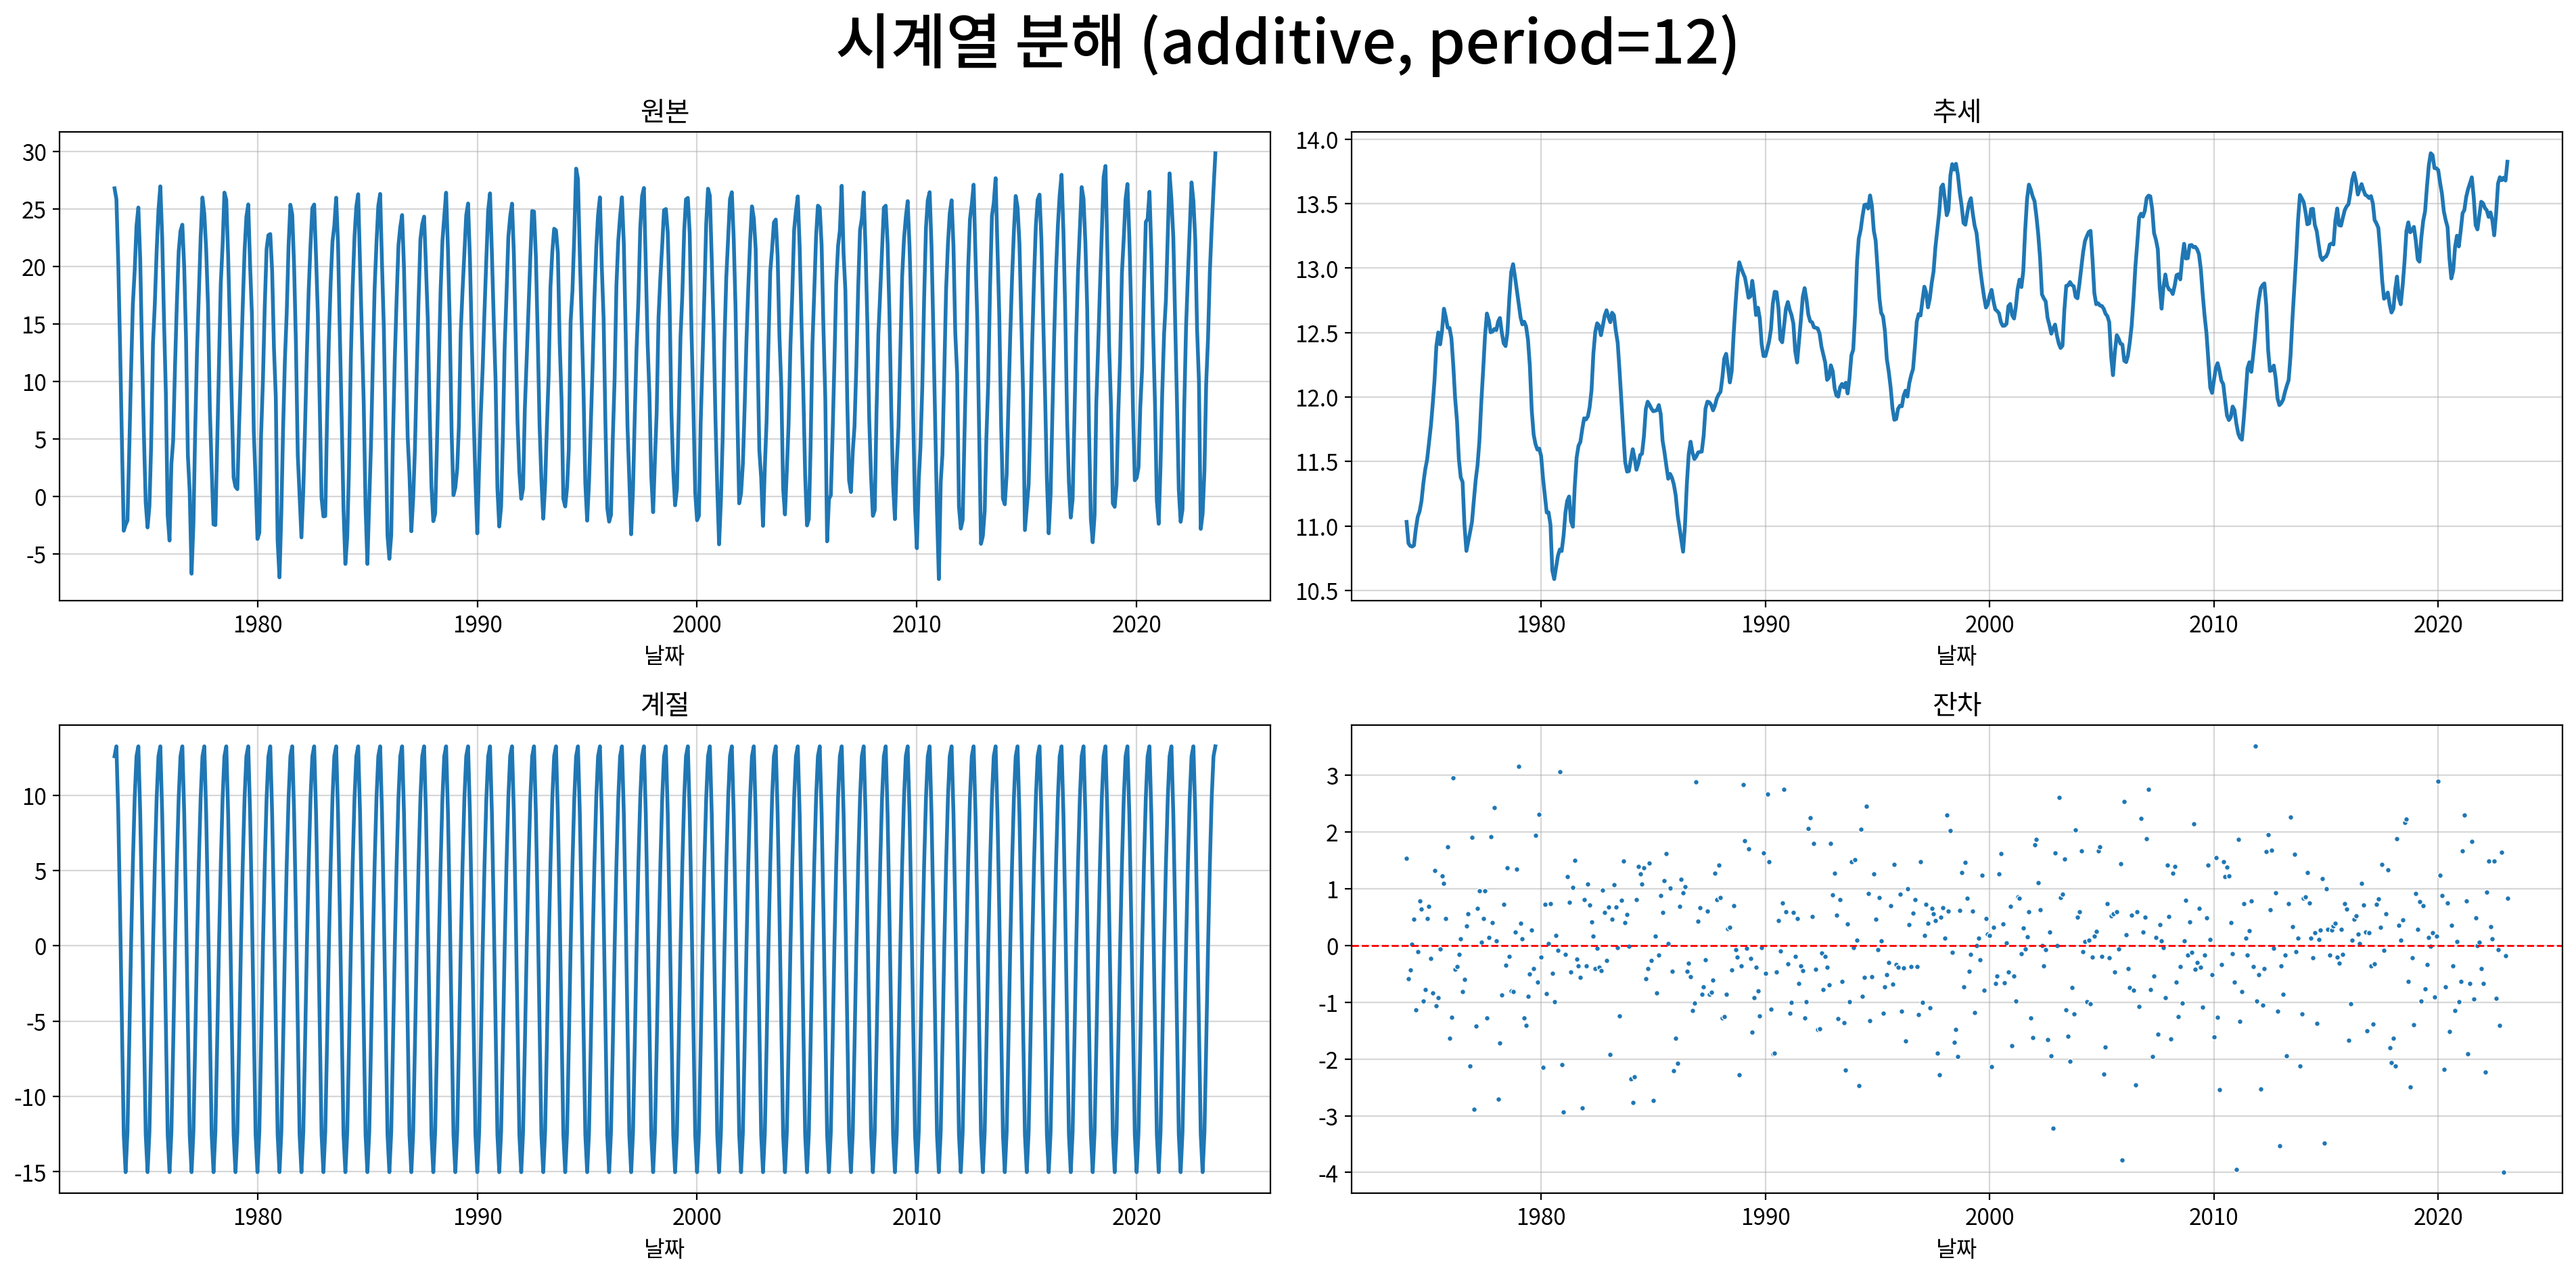

,원본,추세,계절,잔차
날짜,,,,
1974-01-01,-2.458,11.031,-15.024,1.535
1974-02-01,-2.079,10.864,-12.361,-0.582
1974-03-01,3.687,10.845,-6.728,-0.430
1974-04-01,10.720,10.840,-0.136,0.016
1974-05-01,16.665,10.849,5.360,0.456
...,...,...,...,...
2022-10-01,14.565,13.705,2.273,-1.414
2022-11-01,10.030,13.682,-5.288,1.635
2022-12-01,-2.816,13.702,-12.524,-3.994


In [12]:
# model을 주지 않으면 가법/승법을 스스로 판정한다
result1 = my_ts.decompose(df2, 12, "평균기온(℃)")

# 표는 화면에 뿌려지지 않고 반환되므로, 보고 싶으면 마지막 줄에 놓는다
result1.dropna()

In [5]:
result1["계절"].std().round(3)

np.float64(9.809)

결합 방식: additive
최고 위치: 2 (13.2459)
최저 위치: 7 (-15.0241)


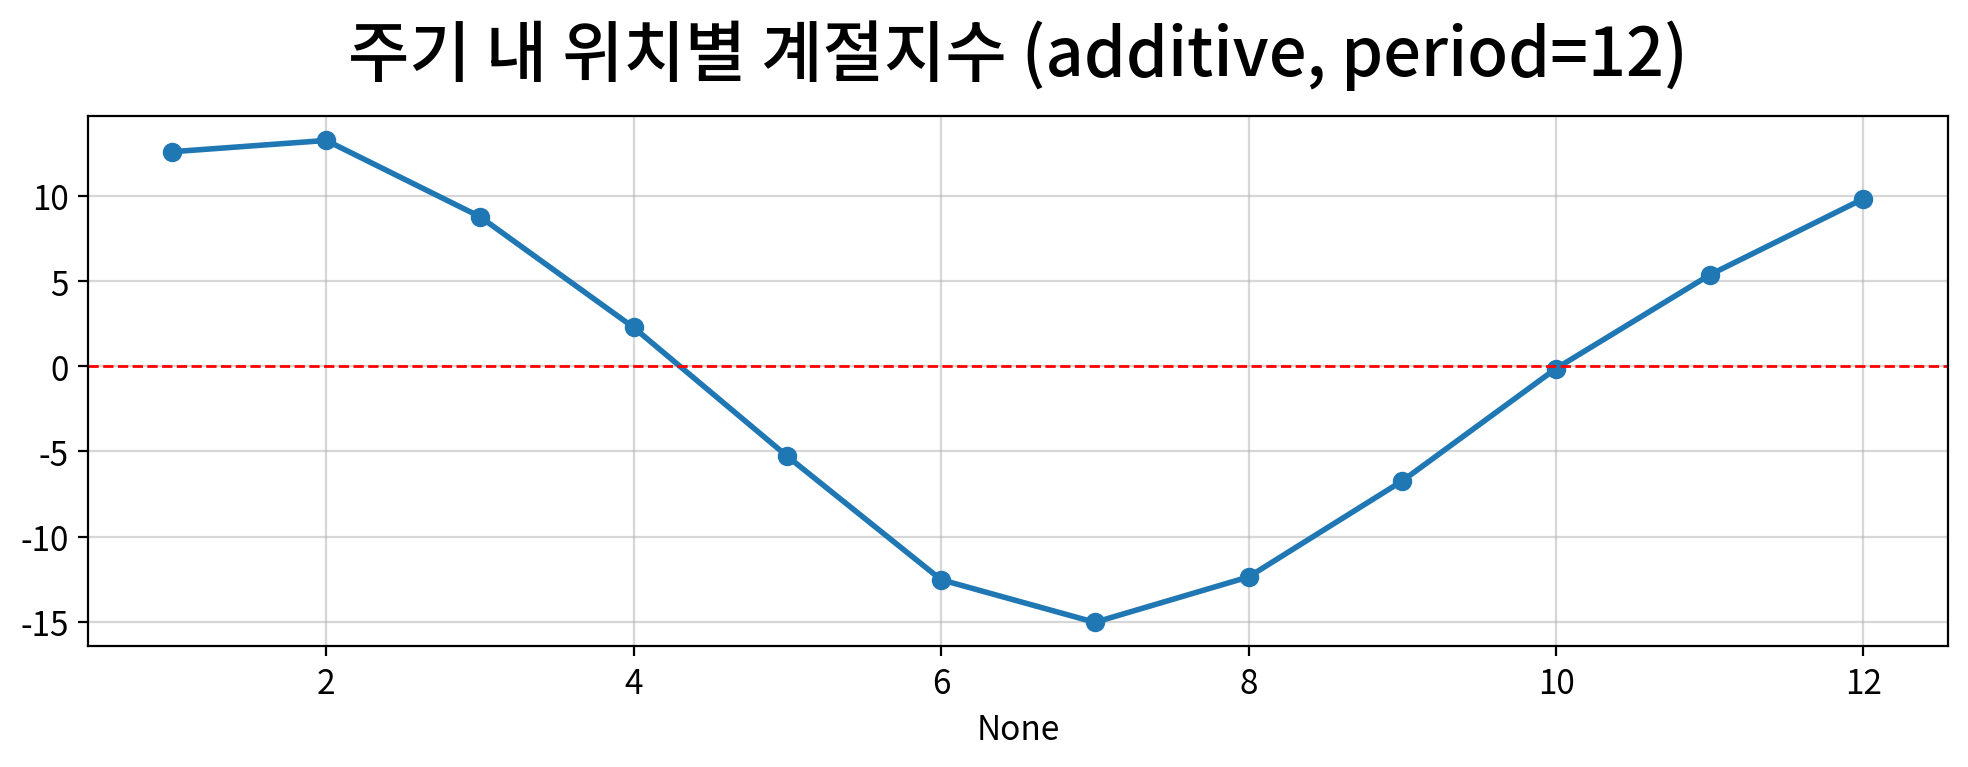

주기 내 위치,1,2,3,4,5,6,7,8,9,10,11,12
계절지수,12.584,13.246,8.773,2.273,-5.288,-12.524,-15.024,-12.361,-6.728,-0.136,5.360,9.824
평균,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000
기준 대비,12.584,13.246,8.773,2.273,-5.288,-12.524,-15.024,-12.361,-6.728,-0.136,5.360,9.824


In [6]:
ss2 = my_ts.report_seasonal(df2, 12, "평균기온(℃)")
ss2.T

In [9]:
print(13.246 - (-15.024))

28.27


결합 방식: additive (원본 − 계절)


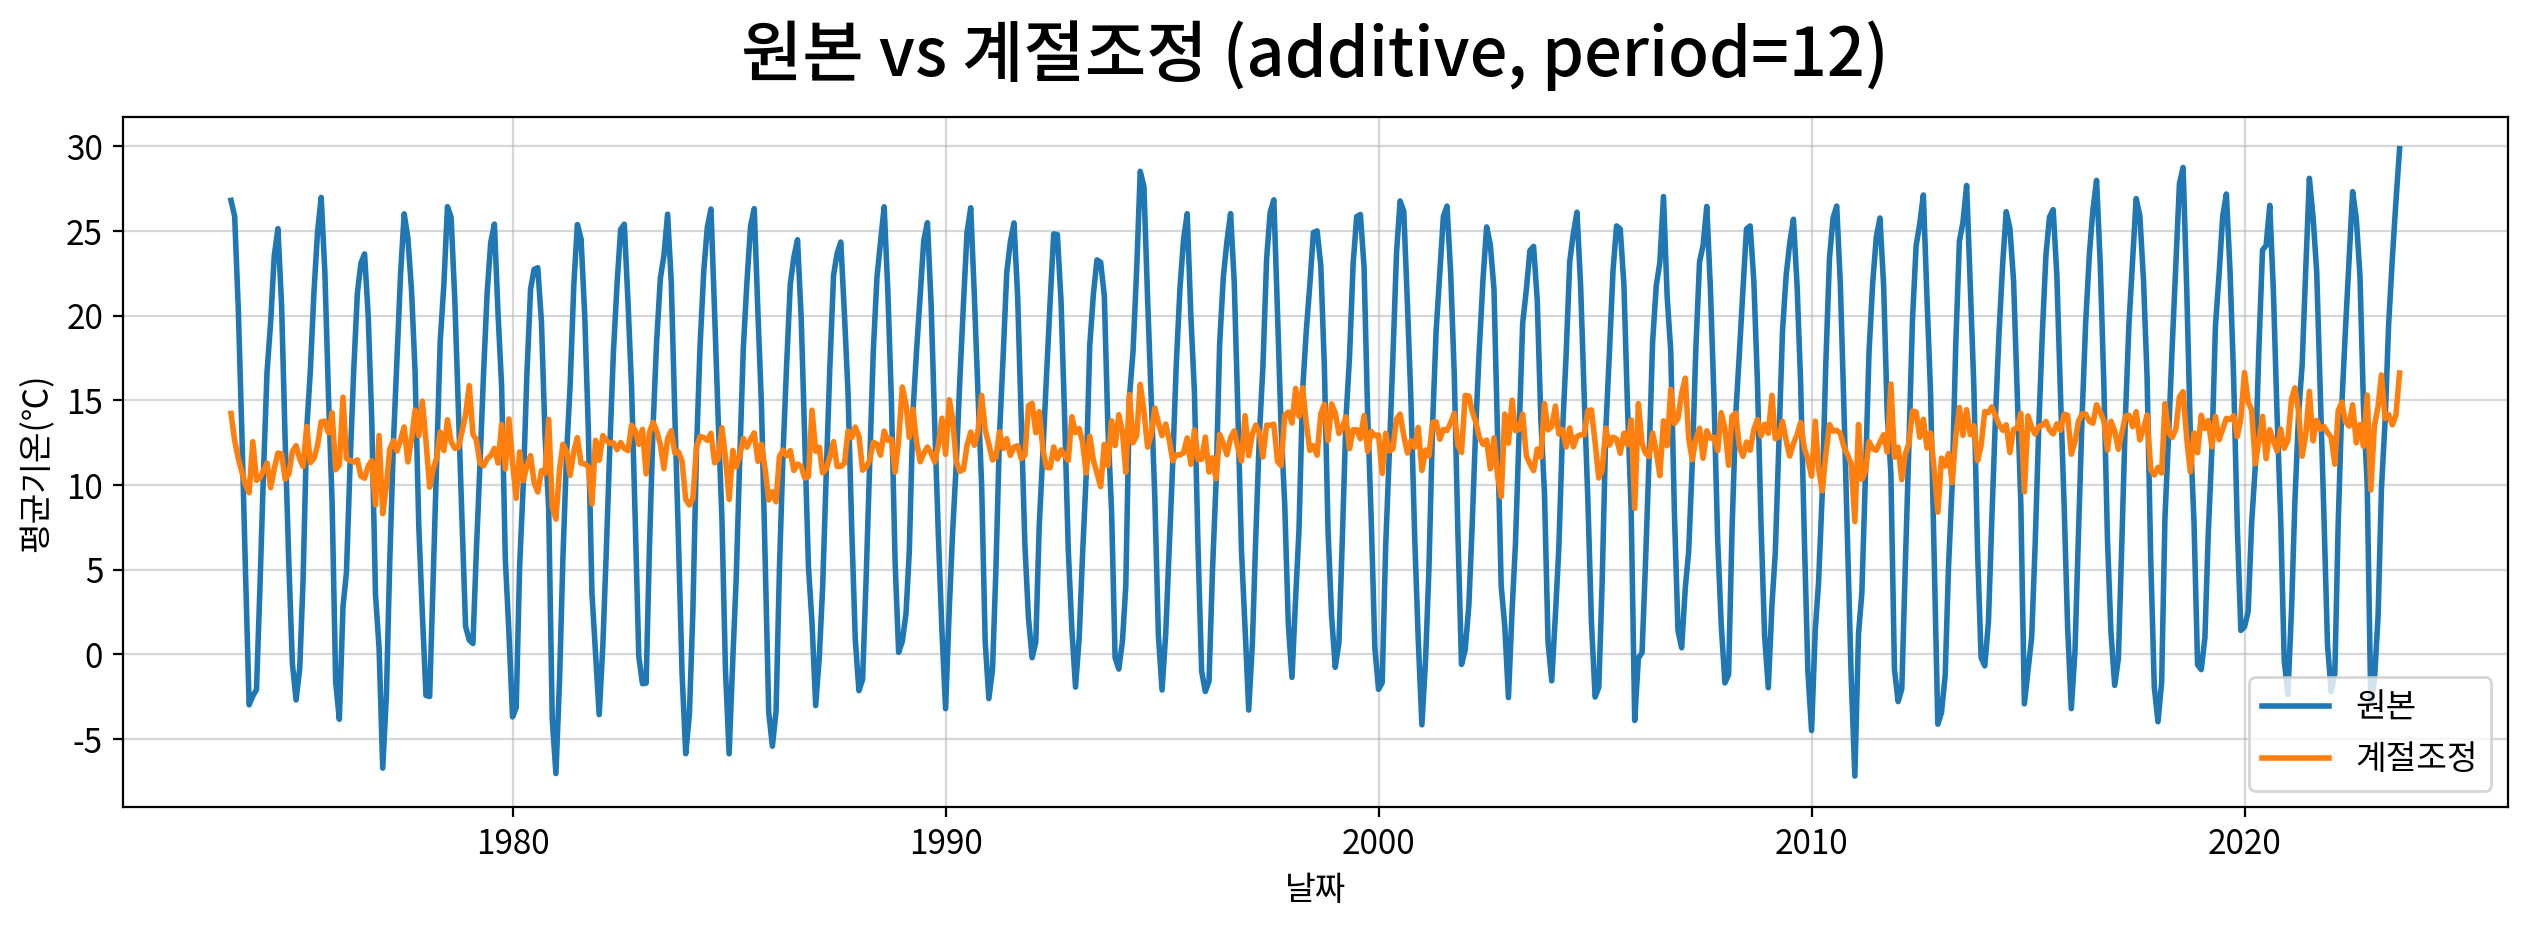

계절조정 : 표준편차 1.450067 | 관측치 602


In [13]:
adjusted2 = my_ts.adjust_seasonal(df2, 12, "평균기온(℃)")
print(f'계절조정 : 표준편차 {adjusted2.std():3f} | 관측치 {len(adjusted2)}')

- 문제 1 : 가법 
- 문제 2 : 9.809
- 문제 3 : -15.024℃ / 7이라고 써있는 부분이 1월임
- 문제 4 : 1.450
- 문제 5 : 590개
- 문제 6 : 계절 조정